## Gráficos fitbit

In [59]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# facilitando acesso às pastas para ambas pessoas analisando os dados
caminho_arquivo = Path('dailyActivity_merged.csv').resolve().parents[1]
print('caminho do diretório',caminho_arquivo)

caminho do diretório D:\python\bellabeat-analysis


In [61]:
d_activity = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/dailyActivity_merged.csv')
heartrate = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/heartrate_seconds_merged.csv')
h_calories = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/hourlyCalories_merged.csv')
h_intensity = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/hourlyIntensities_merged.csv')
m_calories = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/minuteCaloriesNarrow_merged.csv')
m_intensity = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/minuteIntensitiesNarrow_merged.csv')
m_sleep = pd.read_csv(f'{caminho_arquivo}//database/fitbit-data/minuteSleep_merged.csv')
weightlog = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/weightLogInfo_merged_treated.csv')
weightlog_full_id = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/weightLog_full_id.csv')

In [ ]:
sns.set_style('dark')
custom_palette=["#2e0e31", "#5D2F61", "#754B79" ,"#97709B", "#B397B6"]
sns.set_palette(custom_palette)

### Gráfico 1 - uso por feature

In [64]:
# salvar em variáveis os ids unicos de cada feature
id_d_activity = d_activity['Id'].nunique()
id_h_calories = h_calories['Id'].nunique()
id_h_intensity = h_intensity['Id'].nunique()
id_m_calories = m_calories['Id'].nunique()
id_m_intensity = m_intensity['Id'].nunique()
id_m_sleep = m_sleep['Id'].nunique()
id_heartrate = heartrate['Id'].nunique()
id_weightlog = weightlog['Id'].nunique()

In [65]:
#dataframe contendo todas as features e seus ids únicos
ids = pd.Series({'Daily activity': id_d_activity, 'Calories': id_h_calories, 'Exercise intensity': id_h_intensity , 'Sleep':id_m_sleep ,  'Heartrate': id_heartrate, 'Weightlog': id_weightlog })
df_ids = ids.reset_index()
df_ids.columns = ['features', 'count']
df_ids

,features,count
0,Daily activity,35
1,Calories,34
2,Exercise intensity,34
3,Sleep,23
4,Heartrate,14
5,Weightlog,11


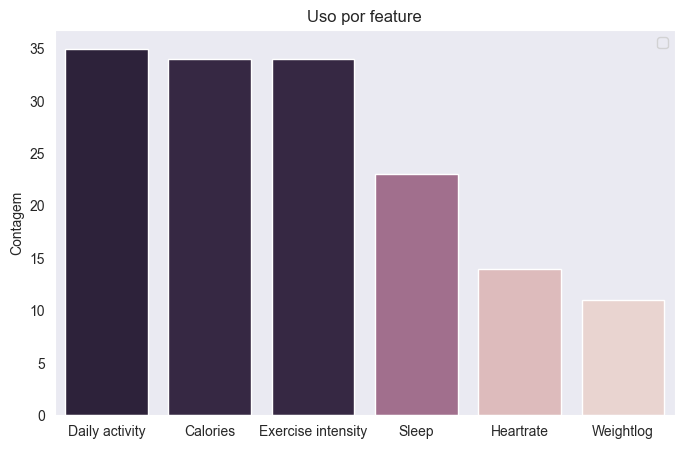

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(data= df_ids, x= 'features', y='count', hue='count')
plt.title('Uso por feature')
plt.xlabel('')
plt.legend('')
plt.xticks(rotation=0)
plt.ylabel('Contagem')
plt.grid(False)
plt.show()

### Gráfico 2 - Tempo de exercício vs intensidade

In [22]:
#obtendo soma de todo tempo de exercício registrado em cada intensidade
fairly_active_minutes_sum = d_activity['FairlyActiveMinutes'].sum()
very_active_minutes_sum = d_activity['VeryActiveMinutes'].sum()
lightly_active_minutes_sum = d_activity['LightlyActiveMinutes'].sum()

In [31]:
# criando dataframe com tempo de exercício em cada intensidade
active_min_sum = pd.Series({'Lightly Active': lightly_active_minutes_sum,'Fairly Active': fairly_active_minutes_sum, 'Very Active': very_active_minutes_sum })
df_active_min_sum = active_min_sum.reset_index()
df_active_min_sum.columns = ['Active type', 'Minutes']
df_active_min_sum = df_active_min_sum.sort_values(by='Minutes', ascending=False)
df_active_min_sum

,Active type,Minutes
0,Lightly Active,77722
2,Very Active,7597
1,Fairly Active,5973


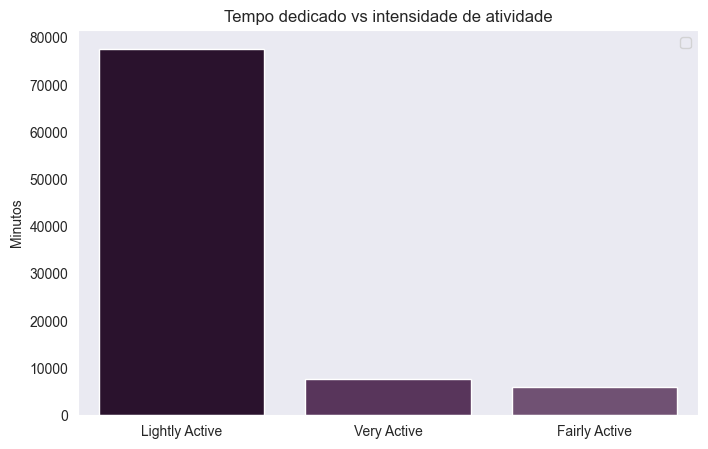

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_active_min_sum, x='Active type', y= 'Minutes', hue='Active type')
plt.title('Tempo dedicado vs intensidade de atividade')
plt.xlabel('')
plt.legend('')
plt.xticks(rotation=0)
plt.ylabel('Minutos')
plt.grid(False)
plt.show()

### Gráfico 3 - Análise de tipo de exercício (distância)

In [28]:
# obter soma de distância em cada intensidade de exercício
fairly_active_distance_sum = d_activity['ModeratelyActiveDistance'].sum()
very_active_distance_sum = d_activity['VeryActiveDistance'].sum()
lightly_active_distance_sum = d_activity['LightActiveDistance'].sum()

In [33]:
# criar dataframe com distância por intensidade
active_distance_sum = pd.Series({'Lightly Active': lightly_active_distance_sum,'Fairly Active': fairly_active_distance_sum, 'Very Active': very_active_distance_sum })
active_distance_sum = active_distance_sum.reset_index()
active_distance_sum.columns = ['Active type', 'Distance']
active_distance_sum = active_distance_sum.sort_values(by='Distance', ascending=False)
active_distance_sum

,Active type,Distance
0,Lightly Active,1320.820000
2,Very Active,539.669999
1,Fairly Active,218.740000


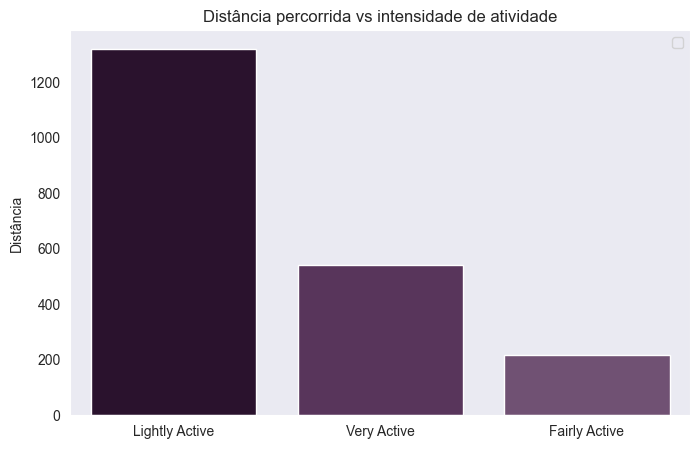

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(data=active_distance_sum, x='Active type', y= 'Distance', hue='Active type')
plt.title('Distância percorrida vs intensidade de atividade')
plt.xlabel('')
plt.legend('')
plt.xticks(rotation=0)
plt.ylabel('Distância')
plt.grid(False)
plt.show()

### Gráfico 4 - comparação entre entradas nulas e com atividade
assumindo que dias sem total steps são dias em que a pessoa não usou o fitbit

In [48]:
# obtendo contagem de valores nulos e ativos em variáveis e dataframe
null_days = d_activity.loc[d_activity['TotalSteps']==0, 'ActivityDate'].value_counts().sum() #61
active_days= d_activity.loc[d_activity['TotalSteps']> 0, 'ActivityDate'].value_counts().sum() #396

active_null_distr = pd.Series({'Nulas' : null_days, 'Ativas' : active_days})
active_null_distr = active_null_distr.reset_index()
active_null_distr.columns = ['Entradas', 'Contagem']
active_null_distr

,Entradas,Contagem
0,Nulas,61
1,Ativas,396


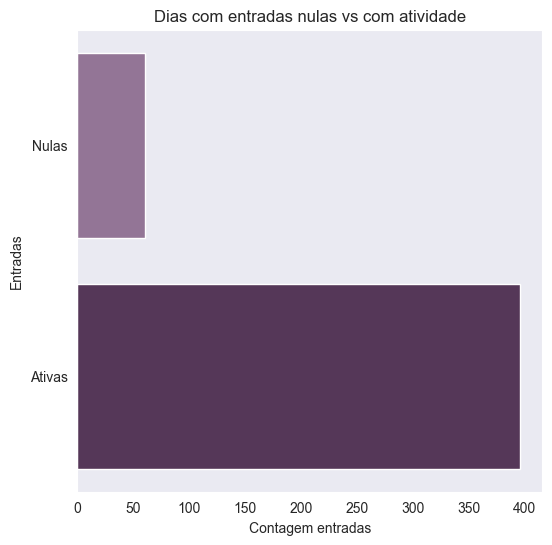

In [51]:
plt.figure(figsize=(6,6))
sns.barplot(data=active_null_distr, x= 'Contagem', y= 'Entradas', hue= 'Entradas', palette=[ "#97709B","#59315E"])
plt.title('Dias com entradas nulas vs com atividade')
plt.xlabel('Contagem entradas')
plt.grid(False)
plt.show()

### Gráfico 5 - distribuição de usuários em categorias de IMC

In [54]:
weight_distr= weightlog_full_id[['Id','BMI_describe']].drop_duplicates()

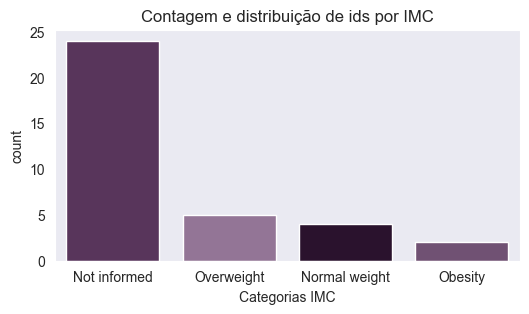

In [58]:
plt.figure(figsize=(6,3))
sns.countplot(data=weight_distr, x='BMI_describe', hue='BMI_describe',order=weight_distr['BMI_describe'].value_counts().index)
plt.title('Contagem e distribuição de ids por IMC')
plt.xlabel('Categorias IMC')
plt.xticks(rotation=0)
plt.grid(False)

plt.show()